# Rice Fertilizer Recommendation Dataset

Dataset: dataset-rekomendasi-pupuk-padi.csv (Kaggle, hamzmiscof):

https://www.kaggle.com/datasets/hamzmiscof/rice-fertilizer-recommendation-dataset

This dataset contains sensor-based measurements used to support fertilizer recommendation for rice (paddy) cultivation. It combines soil and environmental parameters with crop growth stages to determine the most appropriate fertilizer type.

The dataset includes soil moisture, soil temperature, electrical conductivity (EC), air temperature, air humidity, and rice growth phase as input features. The target label represents the recommended fertilizer, such as Urea, ZA, SP-36, NPK 15-10-12, or water flushing.

In [1]:
"""
Columnas:
    moist       -> humedad del suelo (%)
    soilT       -> temperatura del suelo (C)
    EC          -> conductividad electrica del suelo
    airT        -> temperatura del aire (C)
    airH        -> humedad del aire (%)
    Fase_Tanam  -> fase de cultivo (categorica codificada: 0 / 1000)
    Label       -> fertilizante recomendado (target, 6 clases)
"""

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [6]:
DATA_PATH = "/content/dataset-rekomendasi-pupuk-padi.csv"
OUT_DIR = "/mnt/user-data/outputs"

In [7]:
df = pd.read_csv(DATA_PATH)

In [8]:
df.head(5)

,moist,soilT,EC,airT,airH,Fase_Tanam,Label
0,50.6,31.1,2069.0,33.5,93.8,1000,Flushing Air
1,55.4,31.2,1523.0,29.4,89.4,1000,NPK 15-10-12
2,72.3,26.2,1100.0,31.6,76.5,1000,SP-36
3,83.5,25.1,1070.0,33.1,77.1,0,ZA
4,43.0,30.3,623.0,32.3,93.0,0,Urea


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   moist       1000 non-null   float64
 1   soilT       1000 non-null   float64
 2   EC          1000 non-null   float64
 3   airT        1000 non-null   float64
 4   airH        1000 non-null   float64
 5   Fase_Tanam  1000 non-null   int64  
 6   Label       1000 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 54.8+ KB


In [11]:
df.shape

(1000, 7)

In [12]:
df.describe()

,moist,soilT,EC,airT,airH,Fase_Tanam
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,64.777000,28.42470,1566.692000,29.846600,77.522400,482.00000
std,14.389416,2.01888,834.595347,2.377364,10.082953,499.92592
min,40.000000,25.00000,102.000000,26.000000,60.000000,0.00000
25%,52.575000,26.60000,862.000000,27.700000,68.875000,0.00000
50%,63.950000,28.50000,1532.500000,29.700000,77.000000,0.00000
75%,77.200000,30.10000,2302.750000,32.000000,86.000000,1000.00000
max,90.000000,32.00000,2998.000000,34.000000,95.000000,1000.00000


In [13]:
df.dtypes

,0
moist,float64
soilT,float64
EC,float64
airT,float64
airH,float64
Fase_Tanam,int64
Label,object


In [14]:
NUM_COLS = ["moist", "soilT", "EC", "airT", "airH"]
CAT_COLS = ["Fase_Tanam"]
TARGET = "Label"

In [44]:

print("form and types")
print("=" *45)
print(f"rows: {df.shape[0]} | Colums: {df.shape[1]}")
print(df.dtypes)


form and types
rows: 1000 | Colums: 7
moist         float64
soilT         float64
EC            float64
airT          float64
airH          float64
Fase_Tanam      int64
Label          object
dtype: object


In [45]:

print("Null Values and Duplicates")
print("=" * 45)
print("NA / cols:")
print(df.isna().sum())
print(f"Duplciates rows: {df.duplicated().sum()}")
## Not Null values . no duplciates neither

Null Values and Duplicates
NA / cols:
moist         0
soilT         0
EC            0
airT          0
airH          0
Fase_Tanam    0
Label         0
dtype: int64
Duplciates rows: 0


In [46]:

print("Dataset Stats for num cols")
print("=" * 80)
print(df[NUM_COLS].describe().T)

Dataset Stats for num cols
        count       mean         std    min      25%      50%      75%     max
moist  1000.0    64.7770   14.389416   40.0   52.575    63.95    77.20    90.0
soilT  1000.0    28.4247    2.018880   25.0   26.600    28.50    30.10    32.0
EC     1000.0  1566.6920  834.595347  102.0  862.000  1532.50  2302.75  2998.0
airT   1000.0    29.8466    2.377364   26.0   27.700    29.70    32.00    34.0
airH   1000.0    77.5224   10.082953   60.0   68.875    77.00    86.00    95.0


In [47]:

print("Fase_Tanam")
print("=" * 30)
print(df["Fase_Tanam"].value_counts())

Fase_Tanam
Fase_Tanam
0       518
1000    482
Name: count, dtype: int64


In [48]:

print("Target Distribution [Label]")
print("=" * 30)
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100
dist = pd.DataFrame({"count": counts, "pct": pct.round(2)})
print(dist)

Target Distribution [Label]
              count   pct
Label                    
Flushing Air    359  35.9
Urea            212  21.2
NPK 15-10-12    145  14.5
ZA              135  13.5
SP-36            87   8.7
KCl              62   6.2


In [21]:
low_freq = dist[dist["pct"] < 1.0]
print(f"minir classes below < 1%: {list(low_freq.index) if len(low_freq) else 'None'}")

minir classes below < 1%: None


In [23]:
flushing_urea = pct.get("Flushing Air", 0) + pct.get("Urea", 0)
print(f" Flushing Air + Urea = {flushing_urea:.1f}%   total "
      f"both target clases made up el ~57% .")


 Flushing Air + Urea = 57.1%   total both target clases made up el ~57% .


In [26]:
print("Num Features Correlation")
print("=" * 40)
corr = df[NUM_COLS].corr()
print(corr.round(2))

Num Features Correlation
       moist  soilT    EC  airT  airH
moist   1.00  -0.04 -0.03 -0.01 -0.01
soilT  -0.04   1.00  0.05  0.01  0.00
EC     -0.03   0.05  1.00 -0.01 -0.04
airT   -0.01   0.01 -0.01  1.00  0.01
airH   -0.01   0.00 -0.04  0.01  1.00


In [29]:
print("Stats per Classes")
print("=" * 54)
print(df.groupby(TARGET)[NUM_COLS].mean().round(2))


Stats per Classes
              moist  soilT       EC   airT   airH
Label                                            
Flushing Air  63.82  28.65  2494.16  29.85  76.88
KCl           85.75  28.13  1117.76  29.35  76.13
NPK 15-10-12  53.24  28.31  1066.67  29.63  77.59
SP-36         72.75  28.16  1100.30  29.91  77.44
Urea          54.93  28.47  1007.08  30.17  78.60
ZA            80.40  28.20  1022.90  29.75  78.17


In [30]:
## Plots

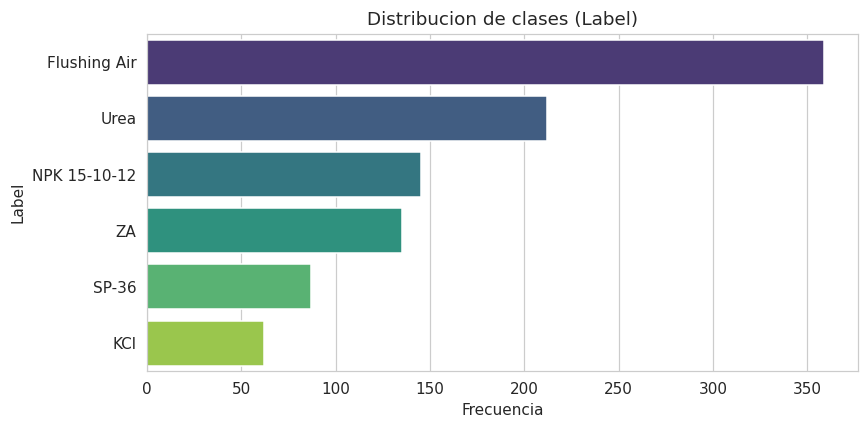

In [34]:
# Target Distribution
plt.figure(figsize=(8, 4))
order = counts.index
sns.barplot(x=counts.values, y=order, hue=order, legend=False, palette="viridis")
plt.title("Distribucion de clases (Label)")
plt.xlabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_01_label_distribution.png")
plt.show()

In [ ]:
# Features Histrogram

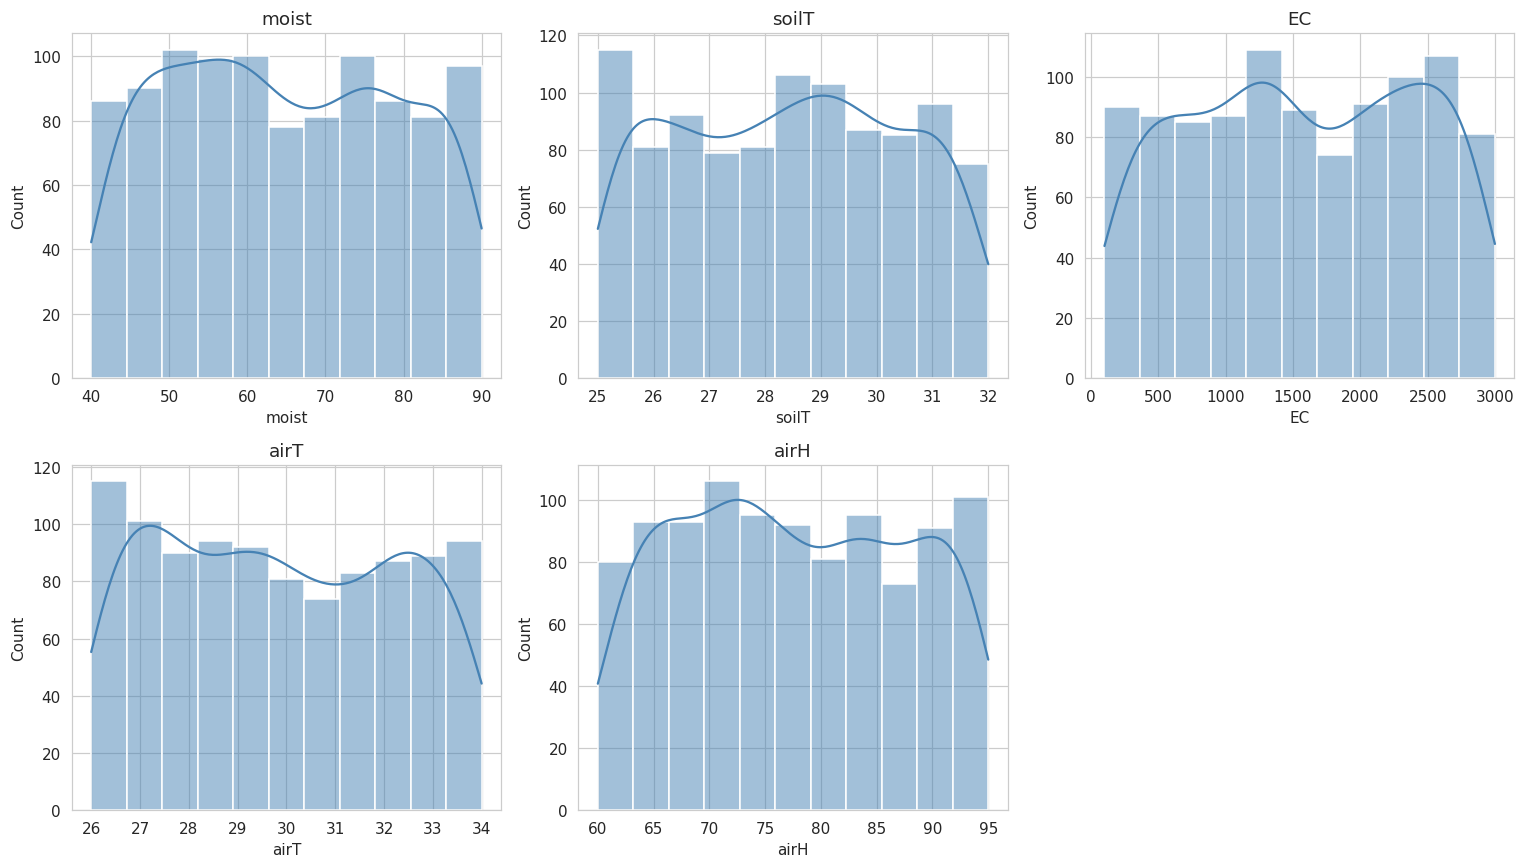

In [36]:
#  Histogramas de features numericas
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, NUM_COLS):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("eda_02_histograms.png")
plt.show()

In [49]:
#

## Boxplots per classes

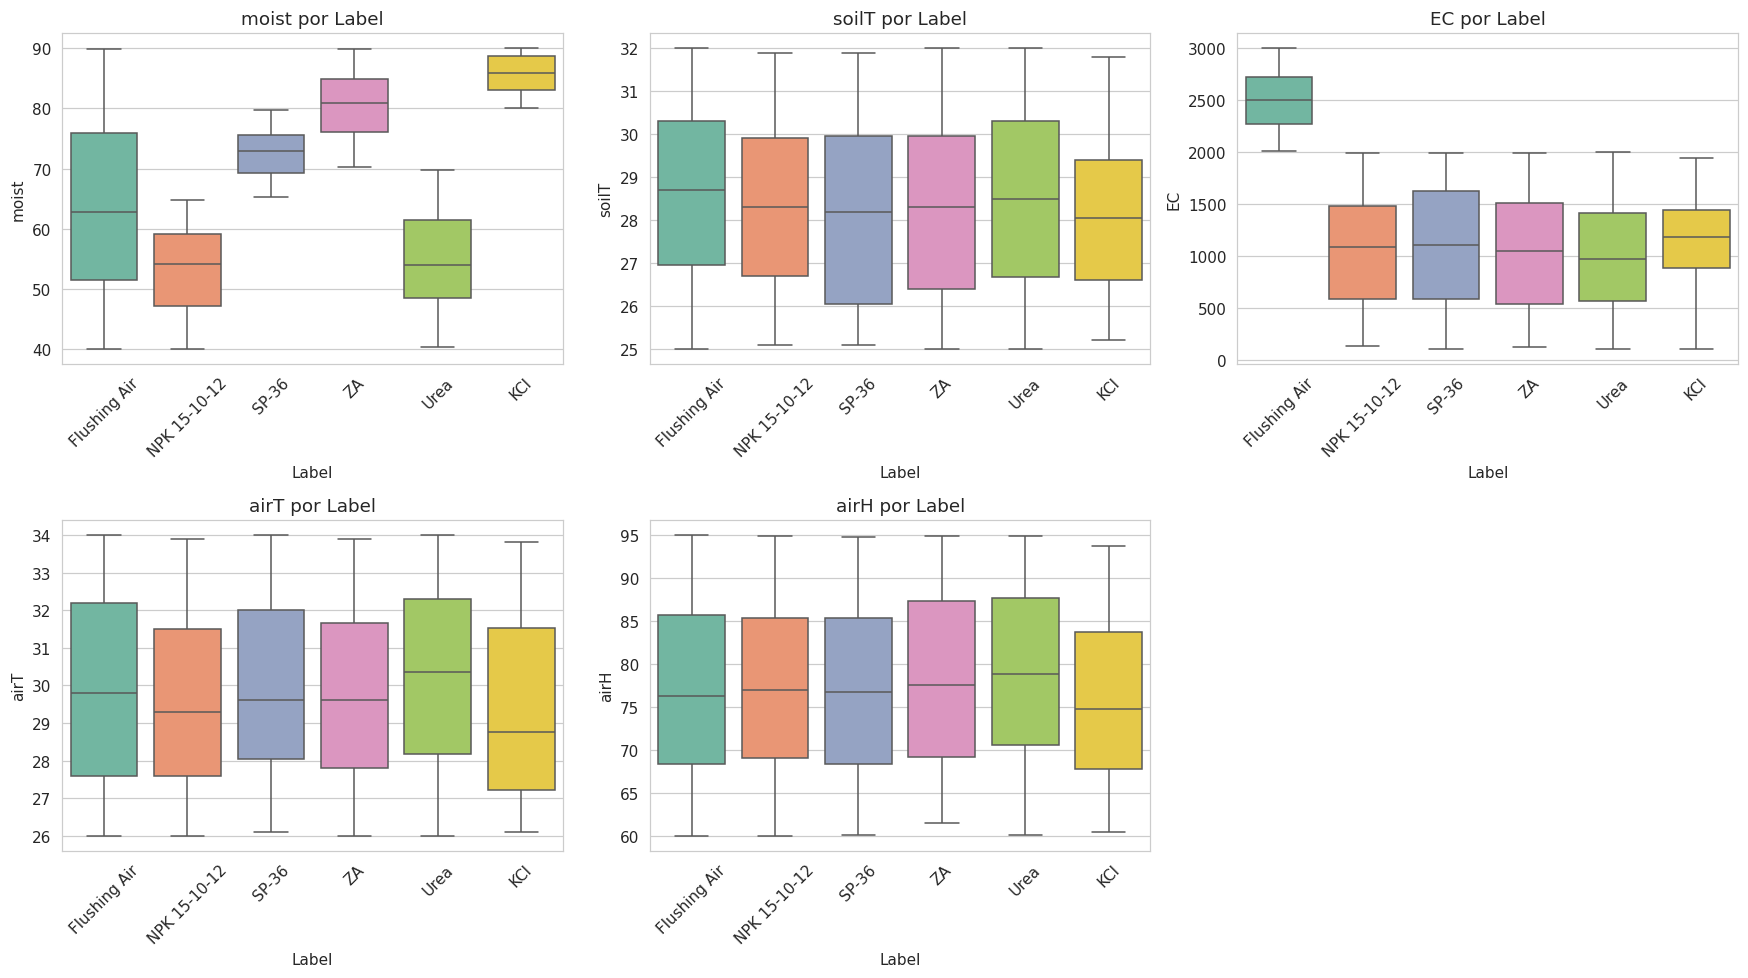

In [51]:
# Boxplots por clase
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, legend=False, ax=ax, palette="Set2")
    ax.set_title(f"{col} por Label")
    ax.tick_params(axis="x", rotation=45)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(f"eda_03_boxplots_por_clase.png")
plt.show()


## Correlation Matrix



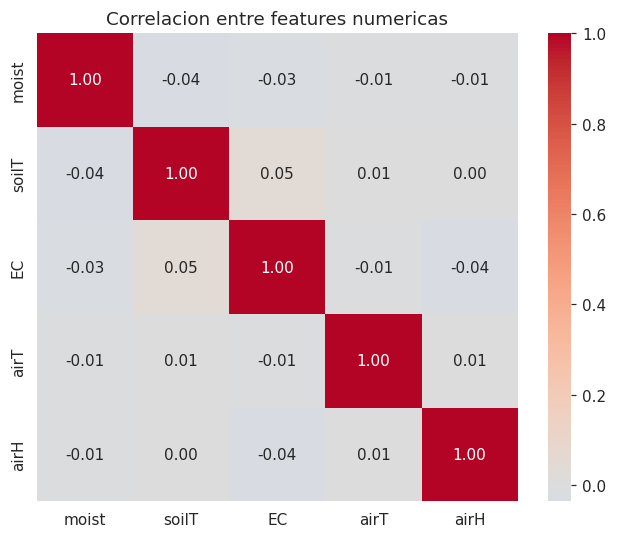

In [37]:
#   Matriz de correlacion
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlacion entre features numericas")
plt.tight_layout()
plt.savefig("eda_04_correlation_heatmap.png")
plt.show()

## Pairplot

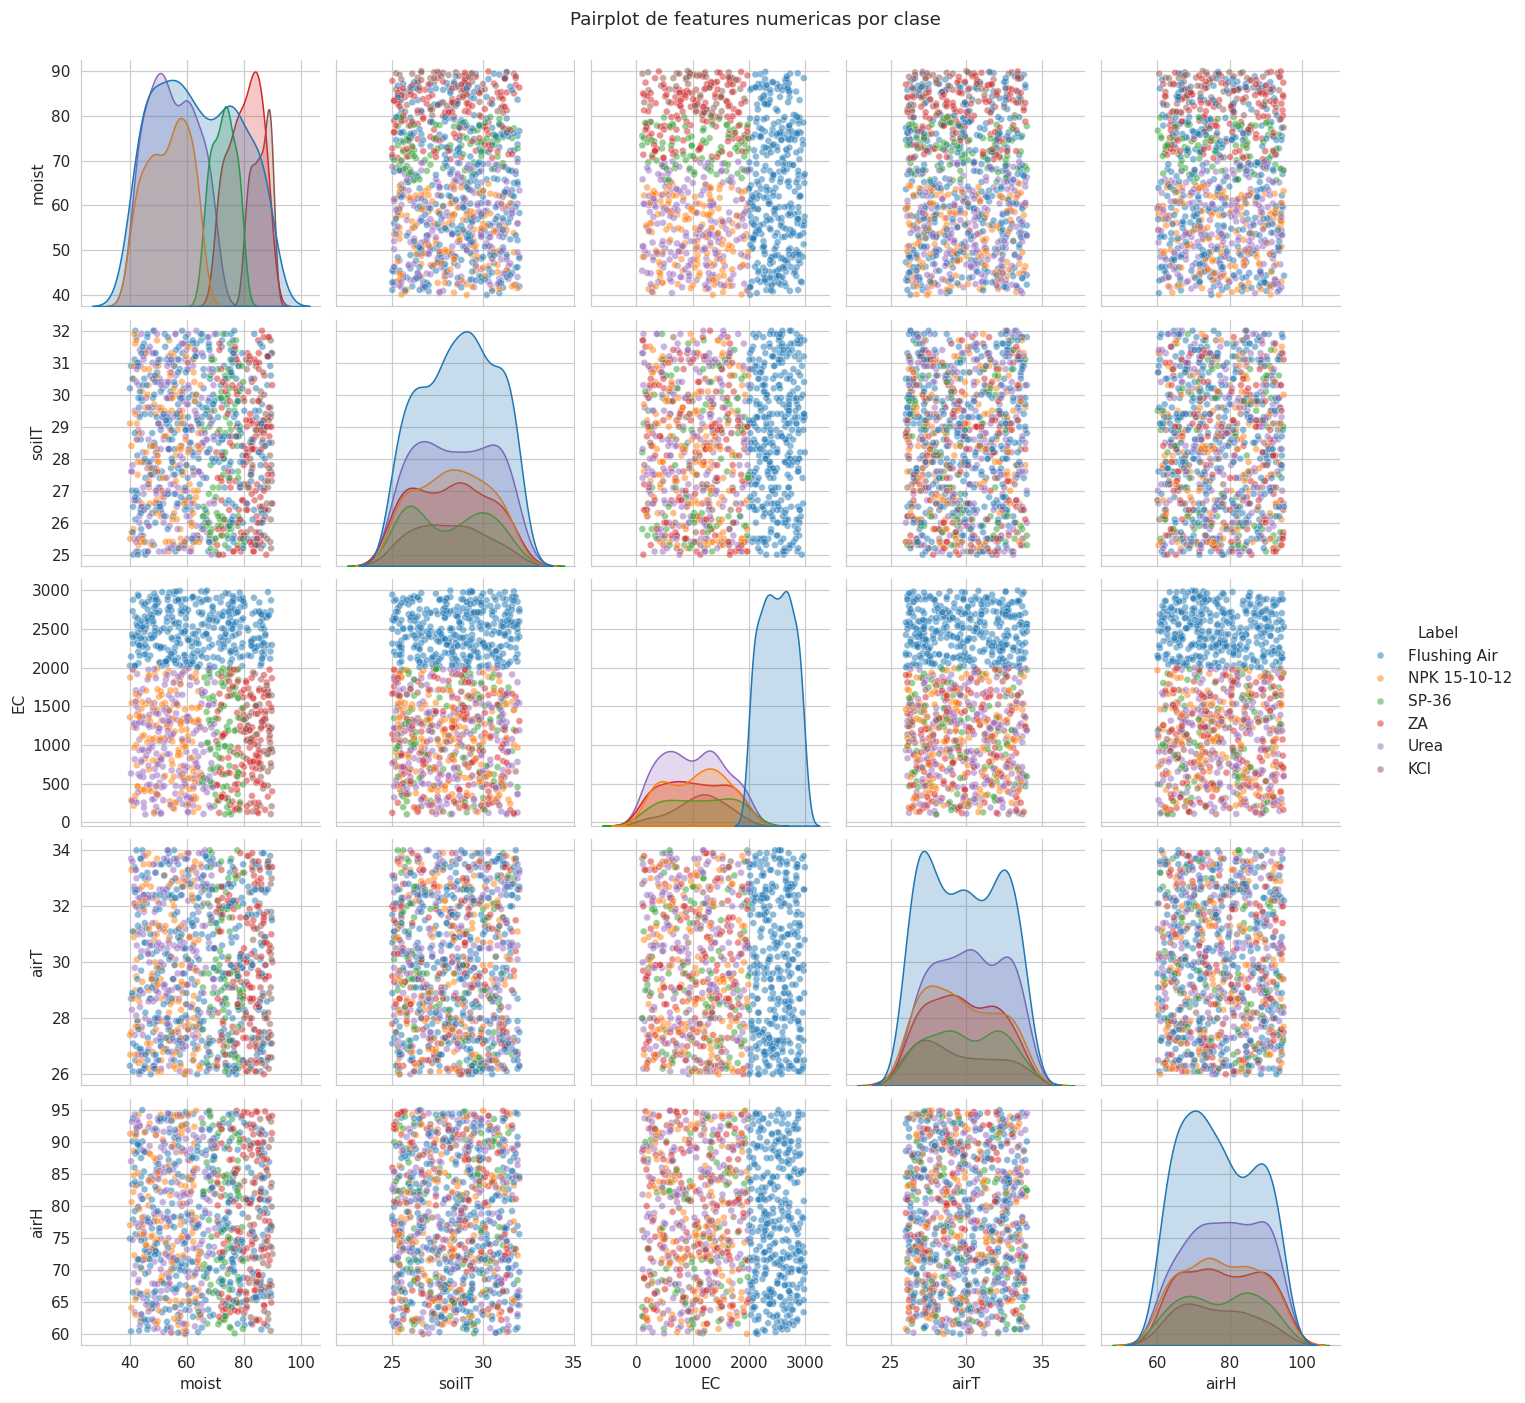

In [38]:
#  Pairplot by classes
pp = sns.pairplot(df, vars=NUM_COLS, hue=TARGET, palette="tab10",
                   plot_kws={"alpha": 0.5, "s": 20}, diag_kind="kde")
pp.fig.suptitle("Pairplot de features numericas por clase", y=1.02)
pp.savefig("eda_05_pairplot.png")
plt.show()


##   Fase_Tanam vs Label

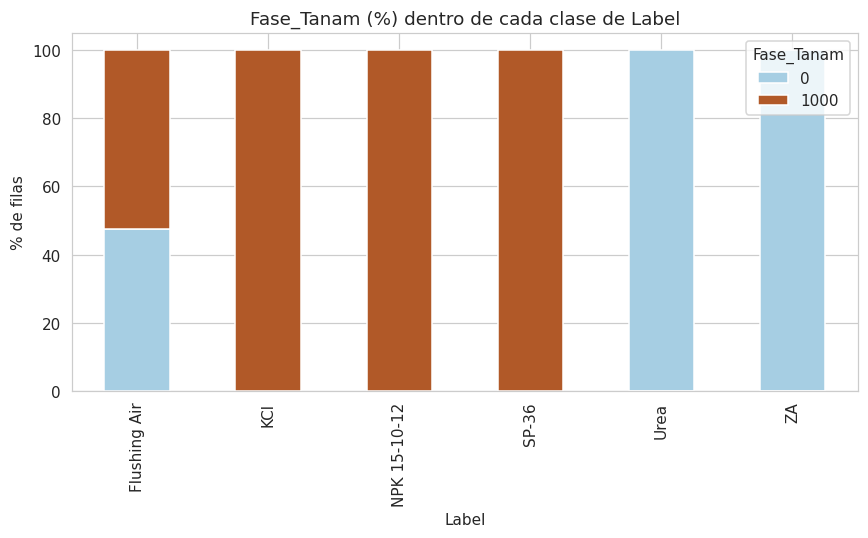

In [40]:
# Fase_Tanam vs Label (tabla cruzada normalizada)
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df[TARGET], df["Fase_Tanam"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, colormap="Paired", ax=plt.gca())
plt.title("Fase_Tanam (%) dentro de cada clase de Label")
plt.ylabel("% de filas")
plt.legend(title="Fase_Tanam")
plt.tight_layout()
plt.savefig(f"eda_06_fase_tanam_vs_label.png")
plt.show()

In [43]:

print("8. Fase_Tanam vs Label Cross Chart")
print("\n" + "=" * 50)
print(ct.round(1))

8. Fase_Tanam vs Label Cross Chart

Fase_Tanam     0      1000
Label                     
Flushing Air   47.6   52.4
KCl             0.0  100.0
NPK 15-10-12    0.0  100.0
SP-36           0.0  100.0
Urea          100.0    0.0
ZA            100.0    0.0


## ML Model


Training a DecisionTreeClassifier on Rice Fertilizer Recommendation .

Dataset: dataset-rekomendasi-pupuk-padi.csv


Target: Label (6 clases: Flushing Air, Urea, NPK 15-10-12, ZA, SP-36, KCl)

In [52]:
import joblib
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text


In [53]:
RANDOM_STATE = 42

In [54]:
OUT_DIR = "/mnt/user-data/outputs"

## Features and target

In [55]:
df["Fase_Tanam"] = (df["Fase_Tanam"] == 1000).astype(int)

In [56]:
FEATURES = ["moist", "soilT", "EC", "airT", "airH", "Fase_Tanam"]
TARGET = "Label"

In [57]:
X = df[FEATURES]
y = df[TARGET]

In [58]:
print("Features:", FEATURES)
print("Target Distrbution:")
print(y.value_counts(normalize=True).round(3) * 100)

Features: ['moist', 'soilT', 'EC', 'airT', 'airH', 'Fase_Tanam']
Target Distrbution:
Label
Flushing Air    35.9
Urea            21.2
NPK 15-10-12    14.5
ZA              13.5
SP-36            8.7
KCl              6.2
Name: proportion, dtype: float64


Train/test split by label stratifed

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [60]:
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows ")

Train: 800 rows | Test: 200 rows 


## Base line model

In [61]:

baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print(f"Accuracy baseline  : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Baseline tree depth: {baseline.get_depth()}")


Accuracy baseline  : 1.0000
Baseline tree depth: 4


## GridSearchCV

Search for best hyper-params

In [62]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

In [63]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",  # f1_macro
    n_jobs=-1,
)


In [64]:
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 8, None],
                         'min_samples_leaf': [1, 2, 5, 10]},
             scoring='f1_macro')

In [65]:
print("Best hyperparams:", grid.best_params_)
print(f" Best F1 : {grid.best_score_:.4f}")

Best hyperparams: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
 Best F1 : 0.9981


In [66]:
model = grid.best_estimator_

In [67]:
#  test assessment
y_pred = model.predict(X_test)

In [68]:
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-macro : {f1_score(y_test, y_pred, average='macro'):.4f}")


Test Accuracy  : 1.0000
F1-macro : 1.0000


In [69]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

Flushing Air       1.00      1.00      1.00        72
         KCl       1.00      1.00      1.00        12
NPK 15-10-12       1.00      1.00      1.00        29
       SP-36       1.00      1.00      1.00        18
        Urea       1.00      1.00      1.00        42
          ZA       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [70]:
## Confusion Matrix

In [71]:

labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

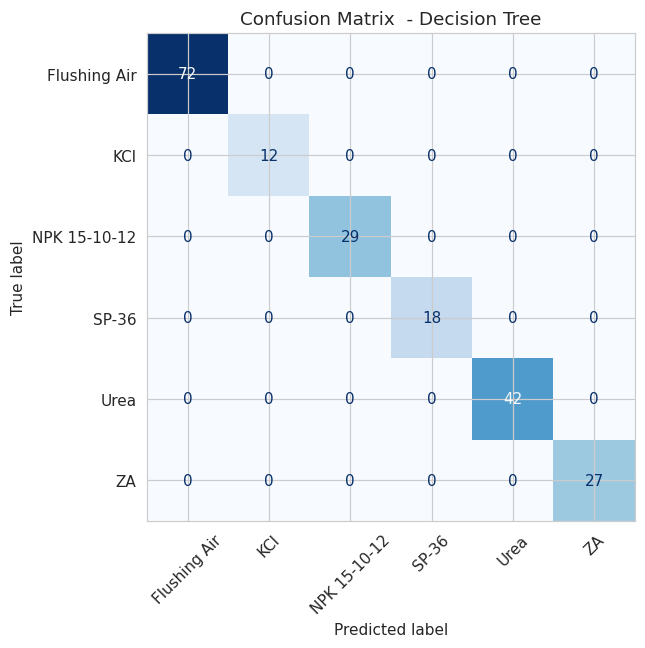

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix  - Decision Tree")
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png")
plt.show()

In [73]:
# Cross Validation

cv_scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
print(f"F1-macro CV (5-fold) over  dataset: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


F1-macro CV (5-fold) over  dataset: 0.9985 +/- 0.0030


In [75]:
## Features Analyisis
importances = pd.Series(model.feature_importances_,
                        index=FEATURES).sort_values(ascending=False)
print("Features Importance:")
print(importances)


Features Importance:
moist         0.449568
EC            0.365699
Fase_Tanam    0.184733
soilT         0.000000
airT          0.000000
airH          0.000000
dtype: float64


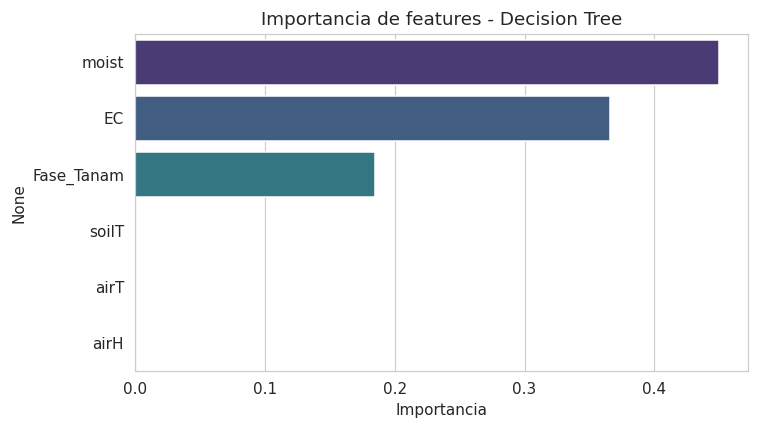

In [76]:
plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            legend=False, palette="viridis")
plt.title("Importancia de features - Decision Tree")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig(f"dt_feature_importance.png")
plt.show()

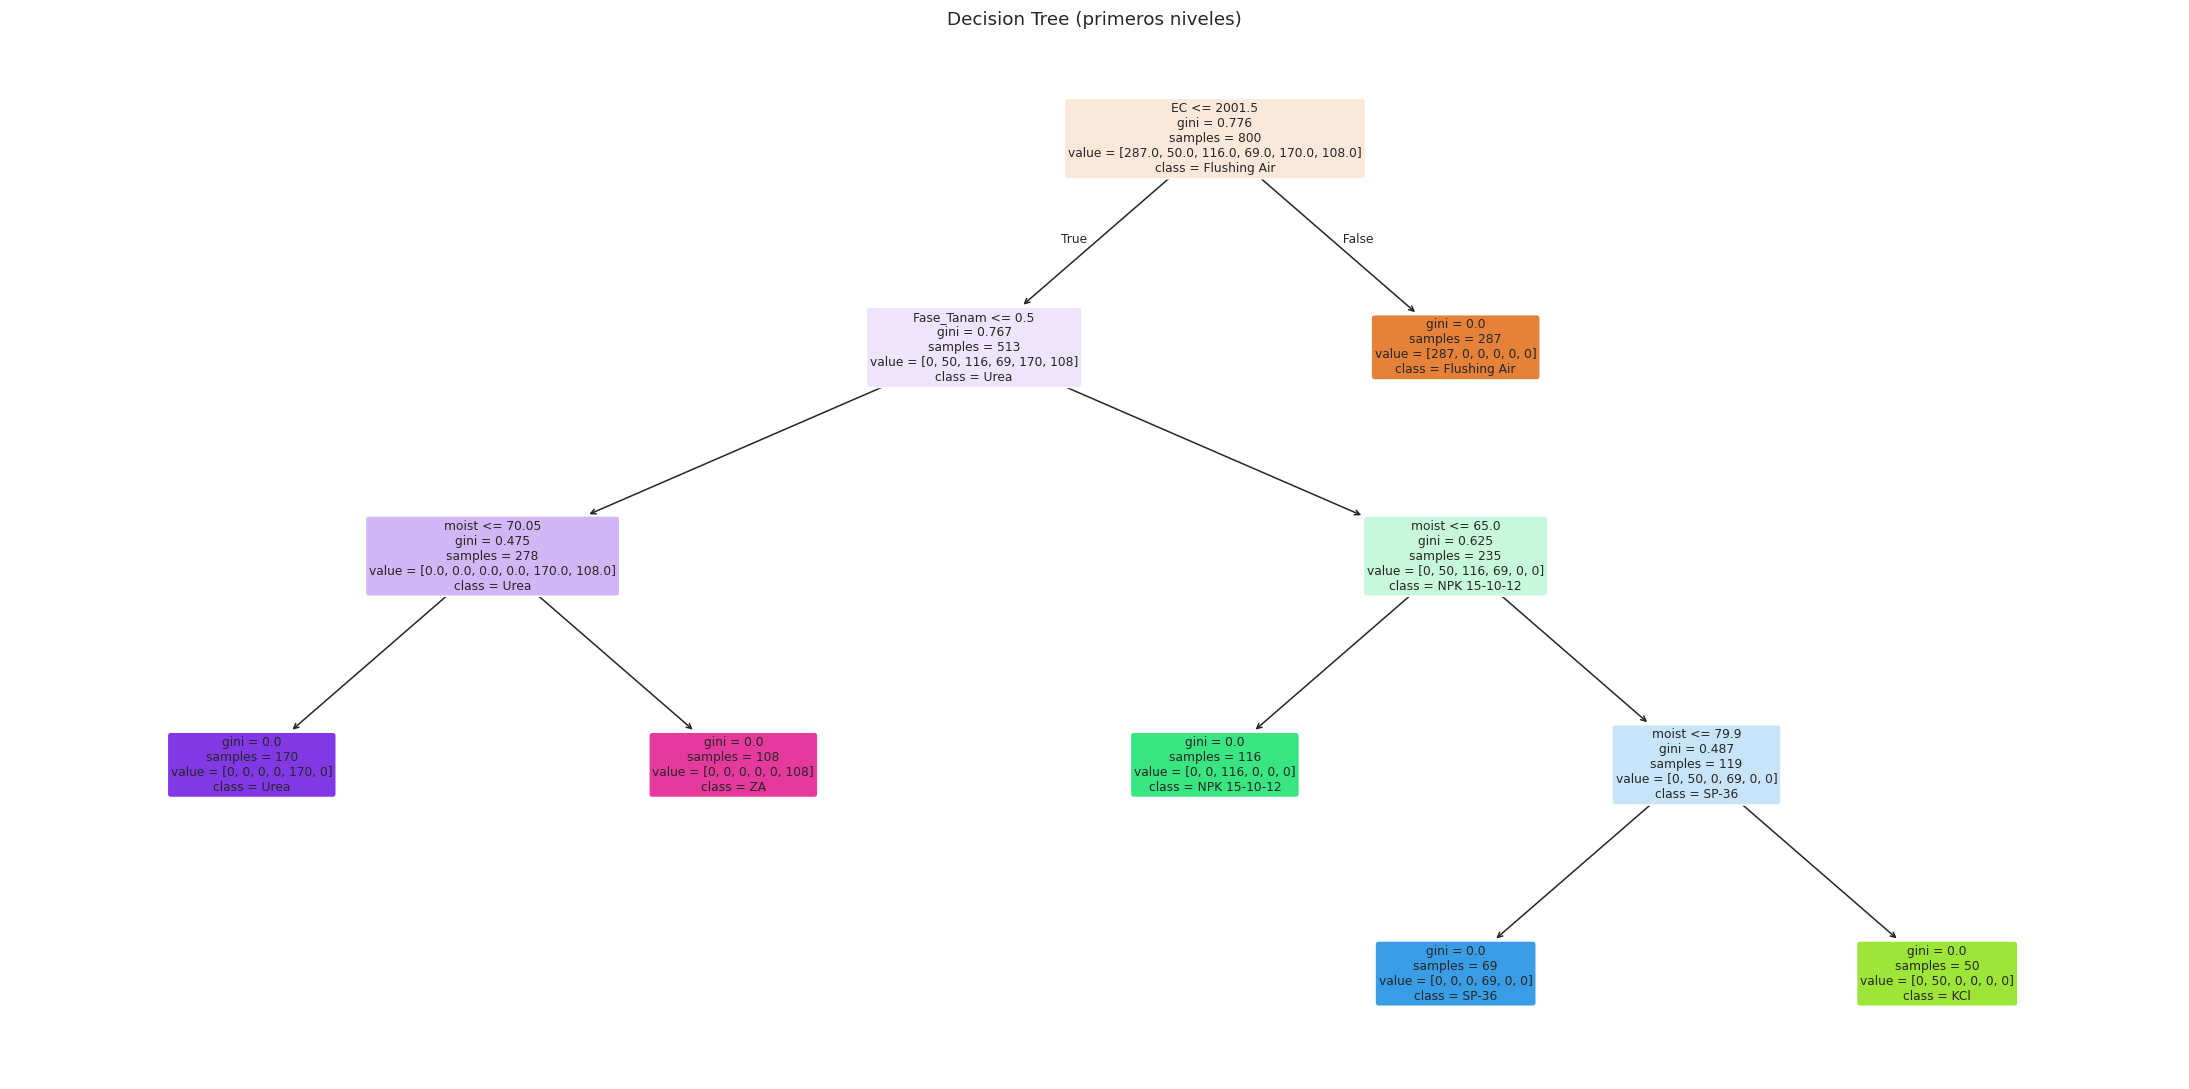

In [78]:
## Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=FEATURES,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,
)
plt.title("Decision Tree")
plt.tight_layout()
plt.savefig(f"dt_tree_plot.png", dpi=150)
plt.show()


In [80]:
tree_rules = export_text(model, feature_names=FEATURES)
with open(f"{OUT_DIR}/dt_tree_rules.txt", "w") as f:
    f.write(tree_rules)
print("Decision tree rules")


Decision tree rules


```
|--- EC <= 2001.50
|   |--- Fase_Tanam <= 0.50
|   |   |--- moist <= 70.05
|   |   |   |--- class: Urea
|   |   |--- moist >  70.05
|   |   |   |--- class: ZA
|   |--- Fase_Tanam >  0.50
|   |   |--- moist <= 65.00
|   |   |   |--- class: NPK 15-10-12
|   |   |--- moist >  65.00
|   |   |   |--- moist <= 79.90
|   |   |   |   |--- class: SP-36
|   |   |   |--- moist >  79.90
|   |   |   |   |--- class: KCl
|--- EC >  2001.50
|   |--- class: Flushing Air


In [82]:
## Save the Model
joblib.dump(model, f"decision_tree_fertilizer.joblib")
print("Model Saved decision_tree_fertilizer.joblib")


Model Saved decision_tree_fertilizer.joblib


In [84]:
print("Report")
print("=" * 70)
print(f"Best Hyperparams: {grid.best_params_}")
print(f"Accuracy test: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-macro test: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-macro CV (5-fold, todo el dataset): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Foremost Features: {importances.index[0]} ({importances.iloc[0]:.3f})")

Report
Best Hyperparams: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Accuracy test: 1.0000
F1-macro test: 1.0000
F1-macro CV (5-fold, todo el dataset): 0.9985 +/- 0.0030
Foremost Features: moist (0.450)


In [ ]:
import joblib
import numpy as np
model = joblib.load("decision_tree_fertilizer.joblib")
# columns: moist, soilT, EC, airT, airH, Fase_Tanam (0 vegetative, 1 reproductive)
X_new = np.array([[50.6, 31.1, 2069.0, 33.5, 93.8, 1]])
model.predict(X_new)